In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/loan_approval_dataset.csv')

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

In [6]:
status_counts = df['loan_status'].value_counts(normalize=True) * 100
print("--- Loan Approval Ratios ---")
print(status_counts)

--- Loan Approval Ratios ---
loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [7]:
cibil_impact = df.groupby('loan_status')['cibil_score'].mean()
print("\n--- Average CIBIL Score by Status ---")
print(cibil_impact)


--- Average CIBIL Score by Status ---
loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64


In [8]:
df_encoded = df.copy()
df_encoded['loan_status_num'] = df_encoded['loan_status'].map({'Approved': 1, 'Rejected': 0})
df_encoded['education_num'] = df_encoded['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_encoded['self_employed_num'] = df_encoded['self_employed'].map({'Yes': 1, 'No': 0})

In [9]:
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_encoded[numeric_cols].corr()

In [10]:
plt.figure(figsize=(18, 6))

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

C:\Users\Testing\AppData\Local\Temp\ipykernel_16016\2063579948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


Text(0.5, 1.0, 'Total Loan Approvals vs Rejections')

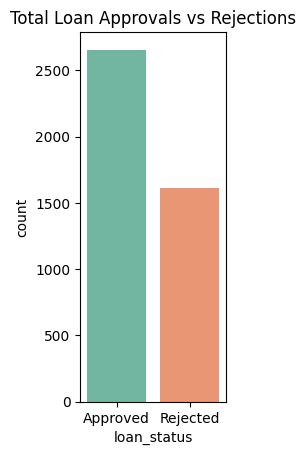

In [11]:
plt.subplot(1, 3, 1)
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Total Loan Approvals vs Rejections')

Text(0.5, 1.0, 'Impact of Education on Loan Status')

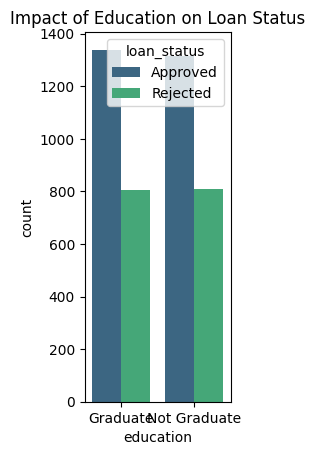

In [12]:
plt.subplot(1, 3, 2)
sns.countplot(x='education', hue='loan_status', data=df, palette='viridis')
plt.title('Impact of Education on Loan Status')

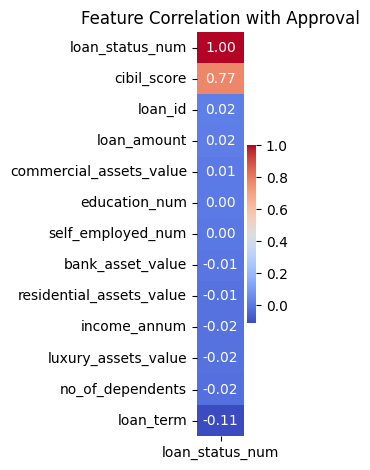

In [13]:
plt.subplot(1, 3, 3)
sns.heatmap(correlation_matrix[['loan_status_num']].sort_values(by='loan_status_num', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Approval')

plt.tight_layout()
plt.show()

C:\Users\Testing\AppData\Local\Temp\ipykernel_16016\3325115806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='income_annum', data=df, palette='pastel')


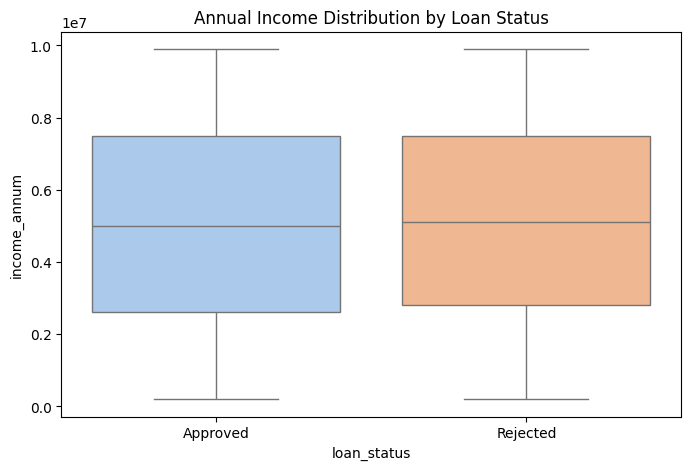

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='income_annum', data=df, palette='pastel')
plt.title('Annual Income Distribution by Loan Status')
plt.show()